# Apply a trained COMIND model to new data

Reconstruct a fitted SubtypingEM from an experiment `.npz` (no re-fit) and
score a table with the **same frozen** preprocessing used at train time.

July 2026 K82 / lnB_lnC NPZs store lognorm `mu`/`sigma` but not
`per_biomarker_min_shift` (recovered from `TRAIN_REF_CSV`).


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import kendalltau

from COMIND_transformer.subtyping_em_transformer import SubtypingEM
from COMIND_transformer.utils import solve_system
from COMIND_transformer.preprocessing import (
    build_connectome,
    lognormal_to_uniform,
    parse_data,
)

NPZ_PATH = (
    "/home/dsemchin/COMIND/experiments/2026_07_02_PPMI_K82_cold_gs_lowscalar_betaclin_betaall/"
    "results/PPMI_subtyping_grid_betajsd_274_lambda_f10p000_lambda_kappa5p000_lambda_cog0p000_"
    "lambda_scalar10p000_scalar_K_center0p010_lambda_jsd10p000_lambda_beta0p000_n_subtypes4.npz"
)
CONNECTOME_PATH = "/home/dsemchin/data/iit_connectivity_matrix/K_82_top10_normalized.csv"
NEW_DATA_CSV = "/home/dsemchin/data/PPMI_deviation_scores.csv"
TRAIN_REF_CSV = NEW_DATA_CSV

OUT_DIR = Path("/home/dsemchin/COMIND/notebooks/apply_model_figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SUBJ_ID_COL = "subj_id"
TIME_COL = "time"
TIME_IN_MONTHS = True

# "both" | "longitudinal" (>=2 visits) | "cross_sectional" (exactly 1 visit)
COHORT_MODE = "cross_sectional"

CLINICAL_COLS = ["MCATOT", "TD_score", "PIGD_score"]
COG_COLS = [f"{c}__raw" for c in CLINICAL_COLS]
METADATA_COLS = ["NHY", "NSD_STAGE"]

Z_SIGN = -1
WINSOR_LIMIT = 6.0
MOCA_CEILING, TD_SCORE_CEILING, PIGD_SCORE_CEILING = 30.0, 20.0, 16.0

_VALID = {"both", "longitudinal", "cross_sectional"}
if COHORT_MODE not in _VALID:
    raise ValueError(f"COHORT_MODE must be one of {_VALID}, got {COHORT_MODE!r}")


### 1. Load trained model


In [24]:
result = np.load(NPZ_PATH, allow_pickle=True)

cluster_f = np.asarray(result["cluster_f"])
cluster_cog_a = np.asarray(result["cluster_cog_a"])
cluster_cog_b = np.asarray(result["cluster_cog_b"])
final_s = np.asarray(result["final_s"])
final_scalar_K = float(result["final_scalar_K"])
final_kappa = np.asarray(result["final_kappa"])
biomarker_names = list(result["biomarker_names"])
n_subtypes = int(result["n_subtypes"])
n_biomarkers = cluster_f.shape[1]
imaging_cols = [b for b in biomarker_names if b not in CLINICAL_COLS]

apply_lognorm_connectome = bool(result["apply_lognorm_connectome"])
apply_lognorm_clinical = bool(result["apply_lognorm_clinical"])

lognorm_connectome_mu = lognorm_connectome_sigma = None
lognorm_clinical_mu = lognorm_clinical_sigma = None
if apply_lognorm_connectome and len(result["lognorm_connectome_mu"]):
    lognorm_connectome_mu = np.asarray(result["lognorm_connectome_mu"], dtype=float)
    lognorm_connectome_sigma = np.asarray(result["lognorm_connectome_sigma"], dtype=float)
if apply_lognorm_clinical and len(result["lognorm_clinical_mu"]):
    lognorm_clinical_mu = np.asarray(result["lognorm_clinical_mu"], dtype=float)
    lognorm_clinical_sigma = np.asarray(result["lognorm_clinical_sigma"], dtype=float)


def recover_affine_shift(ref_csv, imaging_cols, clinical_cols):
    df = pd.read_csv(ref_csv).replace([np.inf, -np.inf], np.nan)
    required = list(imaging_cols) + list(clinical_cols)
    if "PDSTATE" in df.columns:
        group_has_off = df.groupby([SUBJ_ID_COL, TIME_COL])["PDSTATE"].transform(
            lambda s: "OFF" in s.values
        )
        df = df.loc[~((df["PDSTATE"] == "ON") & group_has_off)].copy()
        if df.duplicated(subset=[SUBJ_ID_COL, TIME_COL], keep=False).any():
            def _coalesce(group):
                out = {}
                for col in group.columns:
                    nn = group[col].dropna()
                    out[col] = nn.iloc[0] if len(nn) else np.nan
                return pd.Series(out)
            df = (
                df.sort_values([SUBJ_ID_COL, TIME_COL])
                .groupby([SUBJ_ID_COL, TIME_COL], as_index=False)
                .apply(_coalesce, include_groups=False)
                .reset_index(drop=True)
            )
    df = df.loc[df[required].notna().all(axis=1)].copy()
    z = np.clip(df[imaging_cols].to_numpy(dtype=float), -WINSOR_LIMIT, WINSOR_LIMIT)
    shift = (Z_SIGN * z).min(axis=0)
    print(f"Recovered affine shift from {len(df)} rows; range [{shift.min():.3f}, {shift.max():.3f}]")
    return shift


if "per_biomarker_min_shift" in result.files and len(result["per_biomarker_min_shift"]):
    per_biomarker_min_shift = np.asarray(result["per_biomarker_min_shift"], dtype=float)
else:
    print("per_biomarker_min_shift not in npz -- recovering from TRAIN_REF_CSV")
    per_biomarker_min_shift = recover_affine_shift(TRAIN_REF_CSV, imaging_cols, CLINICAL_COLS)

t_max, t_step = 40, 0.01
t_span = np.linspace(0, t_max, int(t_max / t_step))

em = SubtypingEM(K=None, t_max=t_max, step=t_step, n_subtypes=n_subtypes, lambda_cog=0.0, verbose=0)
em.cluster_f = [np.ravel(cluster_f[k]) for k in range(n_subtypes)]
em.cluster_cog_a = [np.ravel(cluster_cog_a[k]) for k in range(n_subtypes)]
em.cluster_cog_b = [float(cluster_cog_b[k]) for k in range(n_subtypes)]
em.final_s = final_s
em.final_scalar_K = final_scalar_K
em.final_kappa = final_kappa
em.t_span = t_span

print(f"Loaded {n_subtypes}-subtype model, {n_biomarkers} biomarkers")


per_biomarker_min_shift not in npz -- recovering from TRAIN_REF_CSV
Recovered affine shift from 622 rows; range [-6.000, -2.420]
Loaded 4-subtype model, 85 biomarkers


### 2. Load K


In [25]:
K, disconnected = build_connectome(CONNECTOME_PATH, biomarker_names, pad_missing=True)
assert K.shape == (n_biomarkers, n_biomarkers)
em.K = K
print(f"K {K.shape}, disconnected: {disconnected}")


3 biomarker(s) not found in connectome, treated as disconnected nodes: ['MCATOT', 'TD_score', 'PIGD_score']
K (85, 85), disconnected: ['MCATOT', 'TD_score', 'PIGD_score']


### 3. Frozen transform + cohort filter


In [26]:
def transform_new_data(df, per_biomarker_min_shift):
    df = df.copy()
    missing = [c for c in biomarker_names if c not in df.columns]
    if missing:
        raise ValueError(f"Missing biomarkers: {missing[:5]}")

    for raw_name, col in zip(COG_COLS, CLINICAL_COLS):
        df[raw_name] = df[col].to_numpy(dtype=float)

    z = np.clip(df[imaging_cols].to_numpy(dtype=float), -WINSOR_LIMIT, WINSOR_LIMIT)
    z = np.maximum(0.0, Z_SIGN * z - per_biomarker_min_shift)
    if lognorm_connectome_mu is not None:
        z = lognormal_to_uniform(z, lognorm_connectome_mu, lognorm_connectome_sigma)
    df[imaging_cols] = z

    clinical = np.column_stack([
        (MOCA_CEILING - df["MCATOT"].to_numpy(dtype=float)) / (MOCA_CEILING / WINSOR_LIMIT),
        df["TD_score"].to_numpy(dtype=float) / (TD_SCORE_CEILING / WINSOR_LIMIT),
        df["PIGD_score"].to_numpy(dtype=float) / (PIGD_SCORE_CEILING / WINSOR_LIMIT),
    ])
    if lognorm_clinical_mu is not None:
        clinical = lognormal_to_uniform(clinical, lognorm_clinical_mu, lognorm_clinical_sigma)
    df[CLINICAL_COLS] = clinical

    if TIME_IN_MONTHS:
        df[TIME_COL] = df[TIME_COL].to_numpy(dtype=float) / 12.0
    return df


df_new = pd.read_csv(NEW_DATA_CSV).replace([np.inf, -np.inf], np.nan)
if "PDSTATE" in df_new.columns:
    group_has_off = df_new.groupby([SUBJ_ID_COL, TIME_COL])["PDSTATE"].transform(
        lambda s: "OFF" in s.values
    )
    df_new = df_new.loc[~((df_new["PDSTATE"] == "ON") & group_has_off)].copy()

for col in METADATA_COLS:
    if col not in df_new.columns:
        df_new[col] = np.nan

df_new = df_new.dropna(subset=biomarker_names).copy()
df_new = transform_new_data(df_new, per_biomarker_min_shift)

visit_counts = df_new.groupby(SUBJ_ID_COL).size()
n_long = int((visit_counts > 1).sum())
n_cross = int((visit_counts == 1).sum())
if COHORT_MODE == "longitudinal":
    keep_ids = visit_counts[visit_counts > 1].index
elif COHORT_MODE == "cross_sectional":
    keep_ids = visit_counts[visit_counts == 1].index
else:
    keep_ids = visit_counts.index
df_new = df_new.loc[df_new[SUBJ_ID_COL].isin(keep_ids)].copy()

print(
    f"COHORT_MODE={COHORT_MODE!r}: {df_new[SUBJ_ID_COL].nunique()} subjects / {len(df_new)} rows "
    f"(before filter: {n_long} long, {n_cross} cross)"
)


COHORT_MODE='cross_sectional': 187 subjects / 187 rows (before filter: 126 long, 187 cross)


### 4. Patients + transform


In [27]:
patients = parse_data(
    df_new,
    subj_id_col=SUBJ_ID_COL,
    time_col=TIME_COL,
    X_cols=biomarker_names,
    clinical_cols=COG_COLS,
    metadata_cols=METADATA_COLS,
)

tr = em.transform(patients, use_cognitive_prior=False)
beta_new = np.asarray(tr["beta"], dtype=float)
subtype_new = np.asarray(tr["subtype"], dtype=int)

print(f"Transformed {len(patients)} patients")
print(f"beta: min={beta_new.min():.2f}, max={beta_new.max():.2f}, mean={beta_new.mean():.2f}")
u, c = np.unique(subtype_new, return_counts=True)
print("Subtype counts (1-indexed):", dict(zip((u + 1).tolist(), c.tolist())))


Estimating beta and subtype assignments: 100%|██████████| 187/187 [00:43<00:00,  4.26it/s]

Transformed 187 patients
beta: min=20.52, max=40.00, mean=32.75
Subtype counts (1-indexed): {1: 37, 2: 80, 3: 35, 4: 35}


### 5. Plots

- Imaging / clinical spaghetti (lines if >=2 visits, else points)
- TD/PIGD vs subtype crosstab (raw clinical at analysis visit)
- NHY / NSD violins (final visit if longitudinal patient, else single visit)


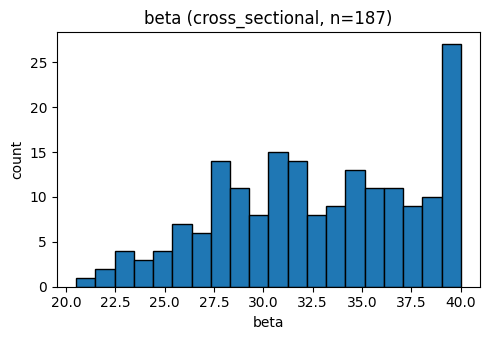

In [ ]:
plt.figure(figsize=(5, 3.5))
plt.hist(beta_new, bins=20, edgecolor="k")
plt.xlabel("beta")
plt.ylabel("count")
plt.title(f"beta ({COHORT_MODE}, n={len(patients)})")
plt.xlim(0, 40)
plt.tight_layout()
plt.savefig(OUT_DIR / "beta_hist.pdf", bbox_inches="tight")
plt.savefig(OUT_DIR / "beta_hist.png", bbox_inches="tight")
plt.show()


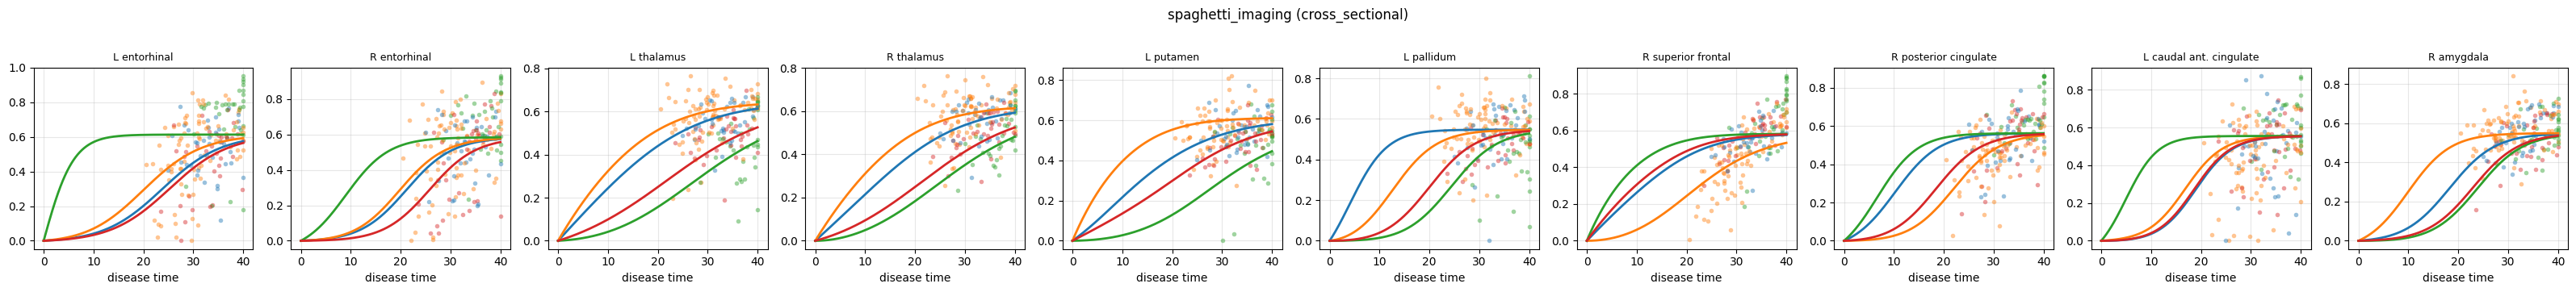

saved /home/dsemchin/COMIND/notebooks/apply_model_figures/spaghetti_imaging.pdf


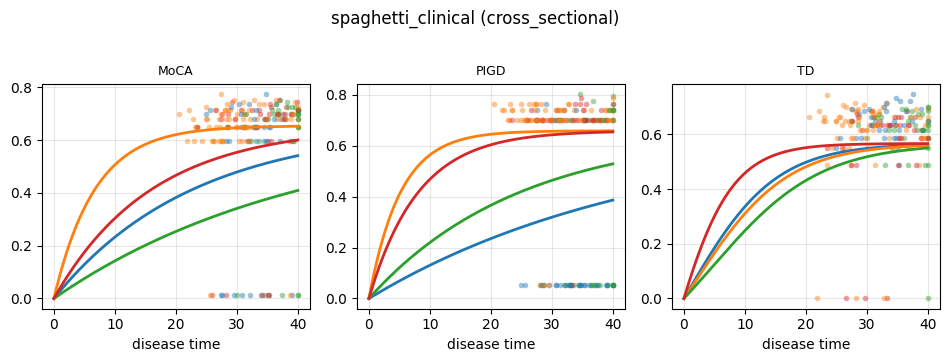

saved /home/dsemchin/COMIND/notebooks/apply_model_figures/spaghetti_clinical.pdf


In [29]:
# Shared helpers for plots
subtype_colors = plt.cm.tab10(np.arange(n_subtypes) / 10.0)
pid_to_beta = {p["id"]: float(beta_new[i]) for i, p in enumerate(patients)}
pid_to_subtype = {p["id"]: int(subtype_new[i]) for i, p in enumerate(patients)}

x0 = np.zeros(n_biomarkers)
traj_by_subtype = [
    solve_system(x0, cluster_f[k], K, t_span, final_scalar_K, final_kappa)
    for k in range(n_subtypes)
]


def analysis_visit_index(p):
    """Final visit if longitudinal, else the only visit."""
    return -1 if len(p["dt"]) >= 2 else 0


def plot_spaghetti(roi_names, title_map, out_stem, max_cols=5):
    idx = [biomarker_names.index(n) for n in roi_names if n in biomarker_names]
    names = [biomarker_names[i] for i in idx]
    if not idx:
        print(f"No ROIs found for {out_stem}")
        return
    n = len(idx)
    ncols = min(max_cols, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(3.2 * ncols, 3.5 * nrows), sharex=True, squeeze=False
    )
    axes_flat = axes.ravel()
    for ax, ridx, name in zip(axes_flat, idx, names):
        for p in patients:
            sub = pid_to_subtype[p["id"]]
            t = p["dt"] + pid_to_beta[p["id"]]
            y = p["X_obs"][:, ridx]
            color = subtype_colors[sub]
            if len(t) >= 2:
                o = np.argsort(t)
                ax.plot(t[o], y[o], color=color, alpha=0.35, lw=1.0)
            else:
                ax.scatter(t, y, color=color, alpha=0.45, s=16, linewidths=0, zorder=2)
        for k in range(n_subtypes):
            ax.plot(
                t_span,
                final_s[ridx] * traj_by_subtype[k][ridx],
                color=subtype_colors[k],
                lw=2,
                zorder=3,
            )
        ax.set_title(title_map.get(name, name), fontsize=9)
        ax.set_xlabel("disease time")
        ax.grid(True, alpha=0.3)
    for ax in axes_flat[n:]:
        ax.set_visible(False)
    fig.suptitle(f"{out_stem} ({COHORT_MODE})", y=1.02)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"{out_stem}.pdf", bbox_inches="tight")
    fig.savefig(OUT_DIR / f"{out_stem}.png", bbox_inches="tight")
    plt.show()
    print("saved", OUT_DIR / f"{out_stem}.pdf")


IMAGING_ROIS = [
    "L_entorhinal_Z_predict",
    "R_entorhinal_Z_predict",
    "Left-Thalamus-Proper_Z_predict",
    "Right-Thalamus-Proper_Z_predict",
    "Left-Putamen_Z_predict",
    "Left-Pallidum_Z_predict",
    "R_superiorfrontal_Z_predict",
    "R_posteriorcingulate_Z_predict",
    "L_caudalanteriorcingulate_Z_predict",
    "Right-Amygdala_Z_predict",
]
IMAGING_TITLES = {
    "L_entorhinal_Z_predict": "L entorhinal",
    "R_entorhinal_Z_predict": "R entorhinal",
    "Left-Thalamus-Proper_Z_predict": "L thalamus",
    "Right-Thalamus-Proper_Z_predict": "R thalamus",
    "Left-Putamen_Z_predict": "L putamen",
    "Left-Pallidum_Z_predict": "L pallidum",
    "R_superiorfrontal_Z_predict": "R superior frontal",
    "R_posteriorcingulate_Z_predict": "R posterior cingulate",
    "L_caudalanteriorcingulate_Z_predict": "L caudal ant. cingulate",
    "Right-Amygdala_Z_predict": "R amygdala",
}
CLINICAL_ROIS = ["MCATOT", "PIGD_score", "TD_score"]
CLINICAL_TITLES = {"MCATOT": "MoCA", "PIGD_score": "PIGD", "TD_score": "TD"}

plot_spaghetti(IMAGING_ROIS, IMAGING_TITLES, "spaghetti_imaging")
plot_spaghetti(CLINICAL_ROIS, CLINICAL_TITLES, "spaghetti_clinical")


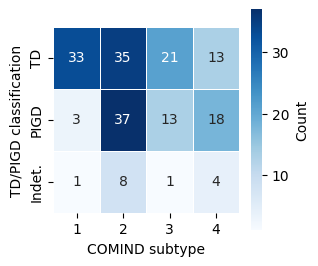

subtype         0   1   2   3
TD_PIGD                      
TD             33  35  21  13
PIGD            3  37  13  18
Indeterminate   1   8   1   4
saved /home/dsemchin/COMIND/notebooks/apply_model_figures/td_pigd_vs_subtype.pdf


In [30]:
# TD/PIGD vs subtype crosstab (raw clinical at analysis visit)
rows = []
for i, p in enumerate(patients):
    j = analysis_visit_index(p)
    td, pigd = float(p["cog"][j, 1]), float(p["cog"][j, 2])
    td_m, pigd_m = td / 10.0, pigd / 3.0
    ratio = np.inf if pigd_m == 0 else td_m / pigd_m
    if ratio >= 1.5 or (td_m > 0 and pigd_m == 0):
        cls = "TD"
    elif ratio <= 1.0 or (td_m == 0 and pigd_m > 0):
        cls = "PIGD"
    else:
        cls = "Indeterminate"
    rows.append({"subtype": int(subtype_new[i]), "TD_PIGD": cls})

ct = pd.DataFrame(rows)
plot_mat = pd.crosstab(ct["TD_PIGD"], ct["subtype"])
for lab in ["TD", "PIGD", "Indeterminate"]:
    if lab not in plot_mat.index:
        plot_mat.loc[lab] = 0
plot_mat = plot_mat.reindex(["TD", "PIGD", "Indeterminate"]).fillna(0).astype(int)
plot_mat = plot_mat.sort_index(axis=1)

fig, ax = plt.subplots(figsize=(3.25, 3.25))
sns.heatmap(
    plot_mat,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[c + 1 for c in plot_mat.columns],
    yticklabels=["TD", "PIGD", "Indet."],
    ax=ax,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Count", "shrink": 0.8},
)
ax.set_xlabel("COMIND subtype")
ax.set_ylabel("TD/PIGD classification")
ax.set_box_aspect(1)
fig.tight_layout()
fig.savefig(OUT_DIR / "td_pigd_vs_subtype.pdf", bbox_inches="tight")
fig.savefig(OUT_DIR / "td_pigd_vs_subtype.png", bbox_inches="tight")
plt.show()
print(plot_mat)
print("saved", OUT_DIR / "td_pigd_vs_subtype.pdf")


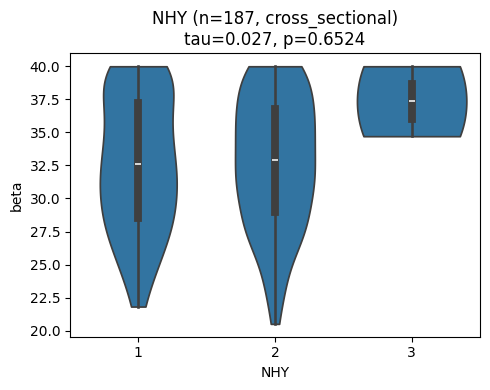

NHY_bin
1    91
2    94
3     2
Name: count, dtype: int64
saved /home/dsemchin/COMIND/notebooks/apply_model_figures/nhy_violin.pdf


In [31]:
# NHY violin (drop 0/missing; merge 4+). Longitudinal patients: final visit y=dt+beta.
def bin_nhy(nhy):
    if pd.isna(nhy):
        return None
    try:
        n = int(round(float(nhy)))
    except (TypeError, ValueError):
        return None
    if n == 0:
        return None
    if n >= 4:
        return "4+"
    return str(n) if n in (1, 2, 3) else None


nhy_rows = []
for i, p in enumerate(patients):
    j = analysis_visit_index(p)
    b = bin_nhy(p["NHY"][j])
    if b is None:
        continue
    long = len(p["dt"]) >= 2
    y = float(p["dt"][j] + beta_new[i]) if long else float(beta_new[i])
    nhy_rows.append({"NHY_bin": b, "NHY_raw": float(p["NHY"][j]), "y": y})
df_nhy = pd.DataFrame(nhy_rows)
order = [c for c in ["1", "2", "3", "4+"] if c in set(df_nhy["NHY_bin"])] if len(df_nhy) else []

tau, pval = (kendalltau(df_nhy["y"], df_nhy["NHY_raw"]) if len(df_nhy) >= 2 else (np.nan, np.nan))
ylab = {
    "longitudinal": "disease time (dt + beta)",
    "cross_sectional": "beta",
}.get(COHORT_MODE, "dt+beta (long) / beta (cross)")

fig, ax = plt.subplots(figsize=(5, 4))
if len(df_nhy):
    sns.violinplot(data=df_nhy, x="NHY_bin", y="y", order=order, ax=ax, cut=0, inner="box")
ax.set_xlabel("NHY")
ax.set_ylabel(ylab)
ax.set_title(f"NHY (n={len(df_nhy)}, {COHORT_MODE})\ntau={tau:.3f}, p={pval:.4g}")
fig.tight_layout()
fig.savefig(OUT_DIR / "nhy_violin.pdf", bbox_inches="tight")
fig.savefig(OUT_DIR / "nhy_violin.png", bbox_inches="tight")
plt.show()
print(df_nhy["NHY_bin"].value_counts().reindex(order, fill_value=0) if len(df_nhy) else "no NHY")
print("saved", OUT_DIR / "nhy_violin.pdf")


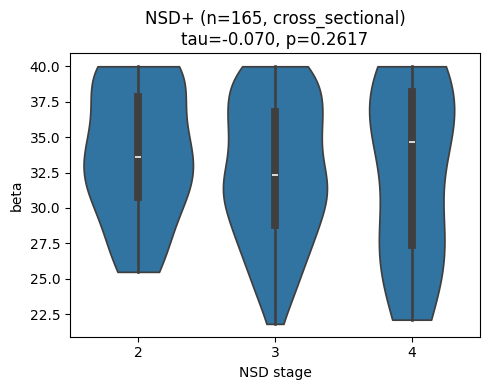

NSD_cat
2     35
3    114
4     16
Name: count, dtype: int64
saved /home/dsemchin/COMIND/notebooks/apply_model_figures/nsd_violin.pdf


In [32]:
# NSD+ violin (drop Not NSD / missing; 2a/2b -> 2)
def parse_nsd(val):
    if pd.isna(val):
        return None
    s = str(val).strip().lower()
    if s in ("not nsd", "nan", "", "none"):
        return None
    if s in ("2a", "2b"):
        return 2
    try:
        n = int(float(s))
    except ValueError:
        return None
    return n if n > 0 else None


nsd_rows = []
for i, p in enumerate(patients):
    j = analysis_visit_index(p)
    nsd = parse_nsd(p["NSD_STAGE"][j])
    if nsd is None:
        continue
    long = len(p["dt"]) >= 2
    y = float(p["dt"][j] + beta_new[i]) if long else float(beta_new[i])
    nsd_rows.append({"NSD": nsd, "NSD_cat": str(nsd), "y": y})
df_nsd = pd.DataFrame(nsd_rows)
order = [str(c) for c in sorted(df_nsd["NSD"].unique())] if len(df_nsd) else []

tau, pval = (kendalltau(df_nsd["y"], df_nsd["NSD"]) if len(df_nsd) >= 2 else (np.nan, np.nan))
ylab = {
    "longitudinal": "disease time (dt + beta)",
    "cross_sectional": "beta",
}.get(COHORT_MODE, "dt+beta (long) / beta (cross)")

fig, ax = plt.subplots(figsize=(5, 4))
if len(df_nsd):
    sns.violinplot(data=df_nsd, x="NSD_cat", y="y", order=order, ax=ax, cut=0, inner="box")
ax.set_xlabel("NSD stage")
ax.set_ylabel(ylab)
ax.set_title(f"NSD+ (n={len(df_nsd)}, {COHORT_MODE})\ntau={tau:.3f}, p={pval:.4g}")
fig.tight_layout()
fig.savefig(OUT_DIR / "nsd_violin.pdf", bbox_inches="tight")
fig.savefig(OUT_DIR / "nsd_violin.png", bbox_inches="tight")
plt.show()
print(df_nsd["NSD_cat"].value_counts().reindex(order, fill_value=0) if len(df_nsd) else "no NSD+")
print("saved", OUT_DIR / "nsd_violin.pdf")
